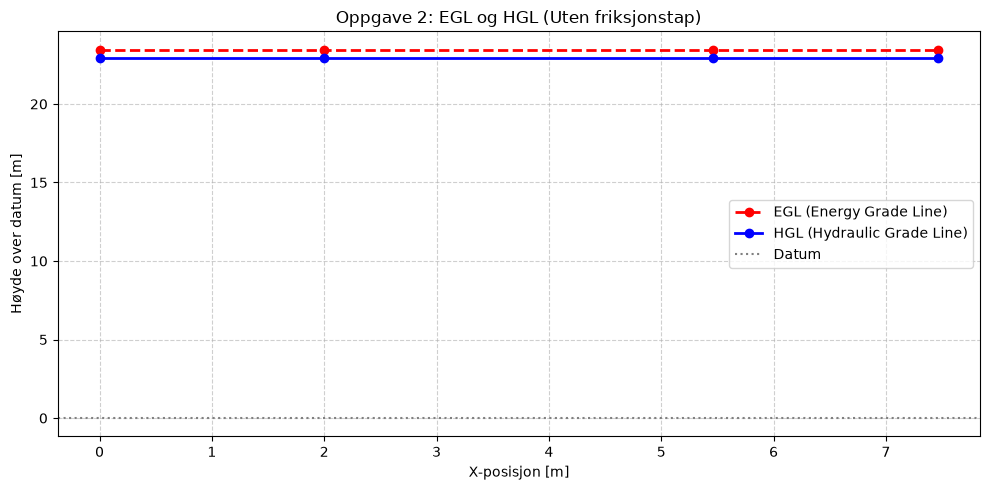

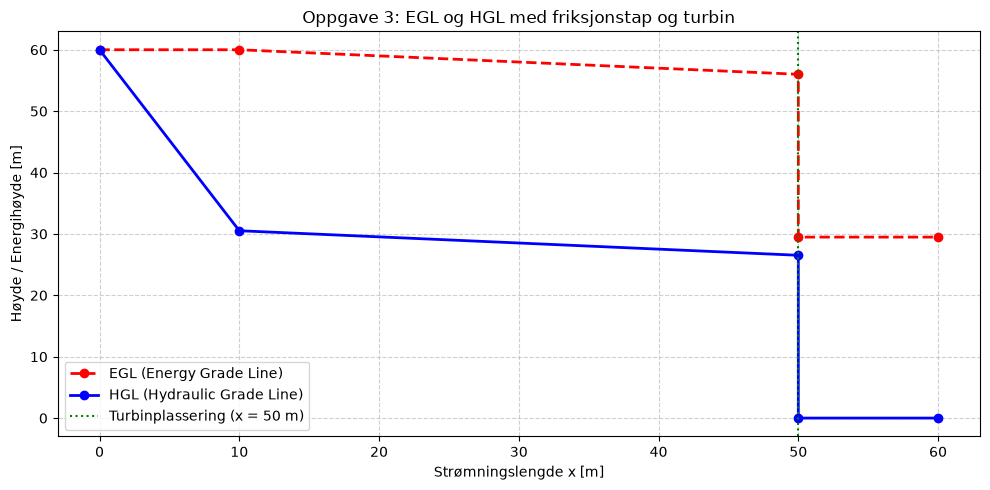

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# felleskonstanter
g = 9.81  # m/s^2
rho = 1000.0  # kg/m^3


def plot_oppgave_2():
    # --- Inndata for Oppgave 2 ---
    P_A = 225000.0  # Pa (225 kPa)
    D = 0.1  # m (100 mm)
    Q = 0.025  # m^3/s

    # Geometri (A -> B -> C -> D)
    # A=(0,0), B=(2,0), C=(2 + 4*cos(30°), 4*sin(30°)), D=(x_C + 2, z_C)
    x_A, z_A = 0.0, 0.0
    x_B, z_B = 2.0, 0.0
    x_C, z_C = 2.0 + 4.0 * np.cos(np.radians(30)), 4.0 * np.sin(np.radians(30))
    x_D, z_D = x_C + 2.0, z_C

    x_pipe = np.array([x_A, x_B, x_C, x_D])
    z_pipe = np.array([z_A, z_B, z_C, z_D])

    # Hastighet og hastighetshøyde (konstant rørdiameter)
    A = np.pi * (D / 2) ** 2
    V = Q / A
    hv = (V**2) / (2 * g)  # Velocity head

    # Trykkhøyde ved A (ideell strømning, intet tap -> EGL er helt horisontal)
    h_pressure_A = P_A / (rho * g)

    # EGL og HGL i meter over datum
    egl = z_A + h_pressure_A + hv * np.ones_like(x_pipe)
    hgl = egl - hv

    # Plott
    plt.figure(figsize=(10, 5))
    # plt.plot(x_pipe, z_pipe, "k-o", linewidth=2.5, label="Rørledning (Senterlinje)")
    plt.plot(x_pipe, egl, "r--o", linewidth=2, label="EGL (Energy Grade Line)")
    plt.plot(x_pipe, hgl, "b-o", linewidth=2, label="HGL (Hydraulic Grade Line)")

    plt.axhline(0, color="gray", linestyle=":", label="Datum")
    plt.title("Oppgave 2: EGL og HGL (Uten friksjonstap)")
    plt.xlabel("X-posisjon [m]")
    plt.ylabel("Høyde over datum [m]")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_oppgave_3():
    # --- Inndata for Oppgave 3 ---
    z_A = 60.0  # Reservoar A høyde [m]
    z_B = 0.0  # Utløp B høyde (Datum) [m]
    D = 0.3  # Rørdiameter [m]
    Q = 1.7  # Volumstrøm [m^3/s]
    h_L = 4.0  # Friksjonstap [m]

    # Beregning av hastighetshøyde
    A = np.pi * (D / 2) ** 2
    V_B = Q / A
    hv = (V_B**2) / (2 * g)

    # Turbinhøyde
    h_t = z_A - hv - h_L

    # Posisoner langs røret:
    # 0 = Reservoar A, 10 = Rørinngang, 50 = Turbin-inngang, 50 = Turbin-utgang, 60 = Utløp B
    x = np.array([0, 10, 50, 50, 60])

    # EGL-verdier:
    # 1. Start ved z_A (stasjonært reservoar)
    # 2. Inngang til rør: synker litt pga. akselerasjon/tap
    # 3. Langs penstock: jevnt lineært tap pga. friksjon (h_L)
    # 4. Gjennom turbin: skarpt fall lik h_t
    # 5. Videre til B: rørutløp
    egl = np.array([z_A, z_A, z_A - h_L, z_A - h_L - h_t, z_A - h_L - h_t])

    # HGL = EGL - V^2/(2g) i røret (i reservoaret er V=0, så HGL=EGL der)
    hgl = np.copy(egl)
    hgl[1:] -= hv  # Trekker fra hastighetshøyden inne i røret

    # Plott
    plt.figure(figsize=(10, 5))
    plt.plot(x, egl, "r--o", linewidth=2, label="EGL (Energy Grade Line)")
    plt.plot(x, hgl, "b-o", linewidth=2, label="HGL (Hydraulic Grade Line)")

    plt.axvline(
        50, color="green", linestyle=":", label="Turbinplassering (x = 50 m)"
    )
    plt.title("Oppgave 3: EGL og HGL med friksjonstap og turbin")
    plt.xlabel("Strømningslengde x [m]")
    plt.ylabel("Høyde / Energihøyde [m]")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Kjør plottene
if __name__ == "__main__":
    plot_oppgave_2()
    plot_oppgave_3()